<a href="https://colab.research.google.com/github/Juni0rResearcher/AdvancedRobotics/blob/main/HW4_Colmap_GaussianSplatting/HW4_Colmap_GaussianSplatting_Iuzhanin_Andrei.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Home assignment 4: 3D-реконструкция объектов методом Gaussian Splatting (GS)

**Задача:** Реализовать конвейер создания фотореалистичного «цифрового двойника» реального объекта, сравнить результаты классического Structure from
Motion (SfM, COLMAP) и нейросетевого рендеринга (3DGS).

**Данные:** Самостоятельная съемка объекта (видео или серия фото). Протокол записи:
1. Выбор объекта: Неподвижный объект с детальной текстурой (избегайте зеркал, стекла и однотонных поверхностей).
2. Съемка: Сделайте 50–100 перекрывающихся фотографий (или видео 30 сек в 4K), обходя объект по кругу на трех разных уровнях высоты.
Перекрытие между кадрами должно быть >70%. Главное — плавные движения, отсутствие размытия (motion blur).
3. Экспорт: Сконвертируйте данные в формат, пригодный для COLMAP (обычно это папка /images).

**Реализация в Jupyter/Colab (на базе camenduru/gaussian-splatting-colab):**
1. Preprocessing (SfM): Чтобы GS заработал, нужно знать положение камеры для каждого кадра. Запустите COLMAP для извлечения облака точек и
параметров камер (Intrinsic/Extrinsic). Рекомендуется применять NerfStudio (ns-process-data) для автовыравнивания, масштабирования, фильтрации.
2. Training (3DGS): Запустите обучение Gaussian Splatting.
    - Проведите два эксперимента: короткое обучение (7k итераций – быстрое формирование сцены) и полное (30k итераций - фотореализм).
    - Попробуйте изменить learning_rate (position_lr_init) для позиций (means) и посмотрите, как это влияет на «разлет» сплэтов.
3. Анализ и Визуализация:
    - Сравнение: Сделайте скриншот разреженного облака точек (COLMAP) и финального рендера (GS) с одного ракурса.
    - Редактирование: Используйте встроенные средства (или скрипты) для обрезки фонового шума (сцены) вокруг объекта.
    - Параметры: Зафиксируйте, как меняется количество «гауссиан» (Splatts) в процессе обучения.
4. Результат: Загрузите в Github ссылку на Colab, скриншоты «до/после» и короткое видео (MP4) облета модели.
Где запускать:
    - Если есть локальная GPU (NVIDIA 8GB+): Использовать среду conda и официальный репозиторий (graphdeco-inria/gaussian-splatting).
    - Если нет GPU: Использовать Google Colab или Kaggle. Помните, что бесплатный T4 в Colab может не вытянуть очень большие сцены (более 200
фото), поэтому 50-70 фото — идеальный баланс.

## 1. Настройка окружения

### 1.1 Установка и импорт необходмиых пакетов

In [1]:
%%capture
!pip install --upgrade numpy

In [1]:
%%capture
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install --upgrade opencv-python pillow numpy matplotlib scipy tqdm
!pip install --upgrade plyfile trimesh

In [2]:
%%capture
# Системные зависимости для COLMAP и компиляции
!apt-get update
!apt-get install -y colmap libgl1-mesa-glx libglib2.0-0 build-essential

# Клонирование репозитория Gaussian Splatting
%cd /content
!git clone --recursive https://github.com/camenduru/gaussian-splatting
!pip install -q plyfile

!cd /content/gaussian-splatting  # Убедитесь, что путь верный
!git submodule update --init --recursive

# Установка подмодулей Gaussian Splatting
%cd /content/gaussian-splatting
!pip install -q /content/gaussian-splatting/submodules/diff-gaussian-rasterization
!pip install -q /content/gaussian-splatting/submodules/simple-knn

# Nerfstudio
%cd /content
!pip install nerfstudio

In [31]:
%%capture
import os
import subprocess

simple_knn_path = "/content/gaussian-splatting/submodules/simple-knn"
cu_file = os.path.join(simple_knn_path, "simple_knn.cu")

with open(cu_file, 'r') as f:
    content = f.read()

# Проверяем, есть ли уже include <cfloat>
if '#include <cfloat>' not in content and '#include <float.h>' not in content:
    # Добавляем после других include
    content = '#include <cfloat>\n' + content

    with open(cu_file, 'w') as f:
        f.write(content)
    print("Добавлен #include <cfloat>")
else:
    print("Include уже присутствует")

build_dir = os.path.join(simple_knn_path, "build")
if os.path.exists(build_dir):
    import shutil
    shutil.rmtree(build_dir)

for root, dirs, files in os.walk(simple_knn_path):
    for file in files:
        if file.endswith('.so') or file.endswith('.o'):
            os.remove(os.path.join(root, file))


%cd {simple_knn_path}
!python setup.py build_ext --inplace

In [32]:
%%capture
%cd /content
!git clone --recursive https://github.com/camenduru/gaussian-splatting
!pip install -q plyfile

%cd /content/gaussian-splatting
!pip install -q /content/gaussian-splatting/submodules/diff-gaussian-rasterization
!pip install -q /content/gaussian-splatting/submodules/simple-knn

In [5]:
%%capture
# Если проблема сохраняется, попробуйте установить конкретную версию CUDA
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# Затем перекомпилируйте
%cd /content/gaussian-splatting/submodules/simple-knn
!python setup.py clean --all
!python setup.py build_ext --inplace

### 1.2 Конфинурация для T4 Tesla в Colab

In [9]:
import torch
import psutil
import os

class T4Config:
    """Автоматическая конфигурация под доступные ресурсы T4"""

    def __init__(self):
        self.gpu_memory_gb = self._get_gpu_memory()
        self.ram_gb = self._get_ram_memory()
        self._configure_parameters()

    def _get_gpu_memory(self):
        """Получить доступную VRAM"""
        if torch.cuda.is_available():
            total_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)
            return total_memory
        return 16.0  # Default for T4

    def _get_ram_memory(self):
        """Получить доступную RAM"""
        return psutil.virtual_memory().total / (1024**3)

    def _configure_parameters(self):
        """Настроить параметры в зависимости от доступной памяти"""

        # Базовые параметры для T4 16GB
        if self.gpu_memory_gb >= 15:
            # T4 16GB - максимальные параметры
            self.max_images = 50
            self.image_resolution = 640  # 640p вместо 720p
            self.max_iterations = 15000
            self.lr_init = 0.0008
            self.batch_size = 1
            self.test_iterations = [7000, 15000]
        elif self.gpu_memory_gb >= 12:
            # T4 12GB - средние параметры
            self.max_images = 50
            self.image_resolution = 512
            self.max_iterations = 10000
            self.lr_init = 0.0005
            self.batch_size = 1
            self.test_iterations = [7000, 10000]
        else:
            # Минимальные параметры
            self.max_images = 20
            self.image_resolution = 512
            self.max_iterations = 7000
            self.lr_init = 0.0003
            self.batch_size = 1
            self.test_iterations = [7000]

        # Общие параметры
        self.position_lr_init = self.lr_init
        self.position_lr_final = self.lr_init * 0.0001
        self.feature_lr = 0.0025
        self.opacity_lr = 0.05
        self.scaling_lr = 0.005
        self.rotation_lr = 0.001
        self.percent_dense = 0.01
        self.lambda_dssim = 0.2
        self.densification_interval = 100
        self.opacity_reset_interval = 3000
        self.densify_from_iter = 500
        self.densify_until_iter = 15000
        self.densify_grad_threshold = 0.0002

        # Адаптация под доступную память
        if self.gpu_memory_gb < 14:
            self.max_iterations = min(self.max_iterations, 10000)
            self.densify_until_iter = min(self.densify_until_iter, 10000)

        if self.gpu_memory_gb < 13:
            self.image_resolution = 512
            self.max_images = min(self.max_images, 30)

    def print_config(self):
        """Вывести конфигурацию"""
        print("=" * 60)
        print("🔧 КОНФИГУРАЦИЯ OPTIMIZED T4")
        print("=" * 60)
        print(f"GPU Memory: {self.gpu_memory_gb:.1f} GB")
        print(f"RAM: {self.ram_gb:.1f} GB")
        print(f"Max Images: {self.max_images}")
        print(f"Image Resolution: {self.image_resolution}p")
        print(f"Max Iterations: {self.max_iterations}")
        print(f"Learning Rate: {self.lr_init}")
        print(f"Test Iterations: {self.test_iterations}")
        print("=" * 60)

# Глобальный конфиг
config = T4Config()

### 1.3 Импорт библиотек и монтирование Google Drive

In [10]:
import os
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import shutil
import glob
import zipfile
import json
import subprocess
import sys
import time
import sqlite3
import struct
import multiprocessing
from mpl_toolkits.mplot3d import Axes3D
from tqdm.notebook import tqdm
from datetime import datetime
from pathlib import Path
from PIL import Image

# Монтируем Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Создаем рабочую директорию
WORK_DIR = '/content/gaussian_splatting'
os.makedirs(WORK_DIR, exist_ok=True)
os.chdir(WORK_DIR)

DATA_DIR = os.path.join(WORK_DIR, "data")
os.makedirs(DATA_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1.4 Загрузка собранных данных

Данные собраны на основе видеосъемки объекта в 4К, фотографии получены методов извлечения кадров из видео. В датасете 100 изображений термоса, стоящего на тумбе.

Скопировано 70 изображений в /content/gaussian_splatting/input/images
 Изображения успешно загружены

Всего загружено: 70 изображений


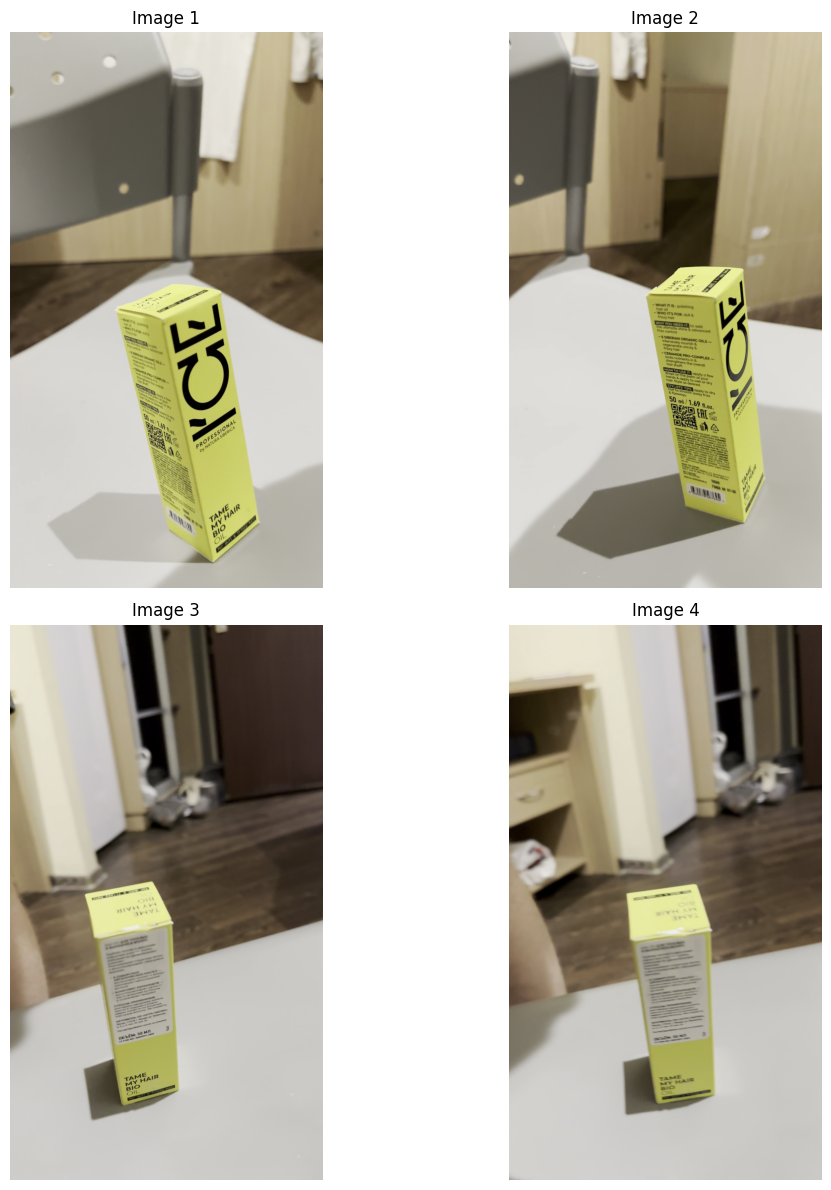

In [11]:
def upload_images_from_drive(drive_path, dest_path):
    """Копирование изображений из Google Drive в рабочую папку"""

    # Путь к папке с изображениями
    source_dir = f'/content/drive/MyDrive/{drive_path}'

    if not os.path.exists(source_dir):
        print(f"Папка {source_dir} не найдена!")
        print("Создайте папку 'robot_hw_images' в Google Drive и загрузите туда 100 изображений")
        return False

    # Создаем папку назначения
    os.makedirs(dest_path, exist_ok=True)

    # Копируем изображения
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
    images = []

    for ext in image_extensions:
        images.extend(glob.glob(os.path.join(source_dir, ext)))

    for img_path in images:
        shutil.copy2(img_path, dest_path)

    print(f"Скопировано {len(images)} изображений в {dest_path}")
    return len(images) > 0

# Загрузка изображений
DRIVE_IMAGES_PATH = "Colab Notebooks/Робототехника/ha4_images"

IMAGES_DIR = os.path.join(WORK_DIR, "input/images")
os.makedirs(IMAGES_DIR, exist_ok=True)

if upload_images_from_drive(DRIVE_IMAGES_PATH, IMAGES_DIR):
    print(" Изображения успешно загружены")
else:
    print(" Ошибка загрузки изображений. Пожалуйста, проверьте путь в Google Drive")

# Показываем пример загруженных изображений
images = glob.glob(os.path.join(IMAGES_DIR, "*.jpg")) + glob.glob(os.path.join(IMAGES_DIR, "*.JPG"))
images.extend(glob.glob(os.path.join(IMAGES_DIR, "*.png")))
images.extend(glob.glob(os.path.join(IMAGES_DIR, "*.PNG")))

print(f"\nВсего загружено: {len(images)} изображений")

if len(images) > 0:
    # Показываем первые 4 изображения
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    for i, ax in enumerate(axes.flat):
        if i < min(4, len(images)):
            img = cv2.imread(images[i])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(f"Image {i+1}")
            ax.axis('off')
    plt.tight_layout()
    plt.show()

In [12]:
def limit_images(input_dir, max_images=50):
    """
    Ограничиваем количество изображений, сохраняя временную последовательность.
    Берем первые N изображений (по алфавиту/времени съемки).
    """
    # Получаем все изображения и сортируем их (по имени файла = временная последовательность)
    images = sorted(glob.glob(os.path.join(input_dir, "*.[jJ][pP][gG]")))

    if len(images) <= max_images:
        print(f"  Изображений {len(images)} ≤ {max_images}, ограничение не требуется")
        return input_dir

    # Берем первые max_images изображений (сохраняем последовательность)
    selected = images[:max_images]

    # Создаем новую папку
    limited_dir = os.path.join(os.path.dirname(input_dir), f"images_{max_images}")
    os.makedirs(limited_dir, exist_ok=True)

    # Копируем выбранные изображения
    for i, img in enumerate(selected, 1):
        shutil.copy2(img, limited_dir)
        if i % 10 == 0:
            print(f"  Скопировано {i}/{len(selected)} изображений")

    print(f"\n✅ Ограничено до {max_images} изображений (первые {max_images})")
    print(f"   Исходная последовательность сохранена")
    print(f"   Папка: {limited_dir}")

    return limited_dir

# Применяем ограничение
if config.max_images < len(glob.glob(os.path.join(IMAGES_DIR, "*.[jJ][pP][gG]"))):
    IMAGES_DIR = limit_images(IMAGES_DIR, config.max_images)

  Скопировано 10/50 изображений
  Скопировано 20/50 изображений
  Скопировано 30/50 изображений
  Скопировано 40/50 изображений
  Скопировано 50/50 изображений

✅ Ограничено до 50 изображений (первые 50)
   Исходная последовательность сохранена
   Папка: /content/gaussian_splatting/input/images_50


## 2. Вспомогательный функции

### 2.1 Colmap

1. `def run_colmap(images_dir, output_dir)` - функция для запуска пайплайна COLMAP
2. `def extract_camera_info(model_dir, images_dir):` -
функция для извлечения информации о камерах из COLMAP.
3. `def save_camera_info(camera_info, output_dir)` - cохранение информации о камерах для 3DGS

In [14]:
def run_colmap(images_dir, output_dir, target_size=720):
    """
    Запуск COLMAP с корректными параметрами для T4
    """
    from PIL import Image
    from pathlib import Path

    # Сжимаем изображения
    compressed_dir = os.path.join(output_dir, "images_compressed")
    os.makedirs(compressed_dir, exist_ok=True)

    images = sorted(glob.glob(os.path.join(images_dir, "*.[jJ][pP][gG]")))
    print(f"📸 Найдено {len(images)} изображений")

    for img_path in images:
        try:
            img = Image.open(img_path)
            ratio = target_size / max(img.size)
            new_size = (int(img.size[0] * ratio), int(img.size[1] * ratio))
            img_resized = img.resize(new_size, Image.Resampling.LANCZOS)

            output_path = os.path.join(compressed_dir, os.path.basename(img_path))
            img_resized.save(output_path, quality=85, optimize=True)
        except Exception as e:
            print(f"Ошибка обработки {os.path.basename(img_path)}: {e}")

    print(f"✅ Сжато {len(images)} изображений до {target_size}p")

    # COLMAP
    cpu_cores = multiprocessing.cpu_count()
    database_path = os.path.join(output_dir, "database.db")
    sparse_dir = os.path.join(output_dir, "sparse")
    os.makedirs(sparse_dir, exist_ok=True)

    # Шаг 1: Feature extraction
    print("\n🔍 Шаг 1: Извлечение признаков...")
    feature_cmd = [
        "colmap", "feature_extractor",
        "--database_path", database_path,
        "--image_path", compressed_dir,
        "--ImageReader.single_camera", "1",
        "--ImageReader.camera_model", "PINHOLE",
        "--SiftExtraction.use_gpu", "0",
        "--SiftExtraction.num_threads", str(cpu_cores),
        "--SiftExtraction.max_image_size", "1024",
        "--SiftExtraction.max_num_features", "4096"
    ]

    result = subprocess.run(feature_cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("❌ Ошибка извлечения признаков:")
        print(result.stderr)
        return None

    print("✅ Извлечение признаков завершено")

    # Шаг 2: Feature matching
    print("\n🔍 Шаг 2: Сопоставление признаков...")
    matcher_cmd = [
        "colmap", "exhaustive_matcher",
        "--database_path", database_path,
        "--SiftMatching.use_gpu", "0",
        "--SiftMatching.num_threads", str(cpu_cores)
    ]

    result = subprocess.run(matcher_cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("❌ Ошибка сопоставления признаков:")
        print(result.stderr)
        return None

    print("✅ Сопоставление признаков завершено")

    # Шаг 3: Mapper с корректными параметрами
    print("\n🔍 Шаг 3: Построение модели...")

    # Пробуем разные настройки
    mapper_configs = [
        # Вариант 1: Стандартные настройки
        {
            "init_min_tri_angle": "16",
            "multiple_models": "0",
            "max_num_models": "1"
        },
        # Вариант 2: Более мягкие
        {
            "init_min_tri_angle": "12",
            "multiple_models": "1",
            "max_num_models": "3"
        },
        # Вариант 3: Минимальные требования
        {
            "init_min_tri_angle": "10",
            "multiple_models": "1",
            "max_num_models": "5"
        }
    ]

    for i, config in enumerate(mapper_configs, 1):
        print(f"\n  Попытка {i} с init_min_tri_angle={config['init_min_tri_angle']}")

        mapper_cmd = [
            "colmap", "mapper",
            "--database_path", database_path,
            "--image_path", compressed_dir,
            "--output_path", sparse_dir,
            "--Mapper.num_threads", str(cpu_cores),
            "--Mapper.init_min_tri_angle", config["init_min_tri_angle"],
            "--Mapper.multiple_models", config["multiple_models"],
            "--Mapper.extract_colors", "1"
        ]

        # Добавляем max_num_models если указан
        if "max_num_models" in config:
            mapper_cmd.extend(["--Mapper.max_num_models", config["max_num_models"]])

        result = subprocess.run(mapper_cmd, capture_output=True, text=True)

        if result.returncode == 0:
            print("✅ Построение модели завершено!")

            # Ищем успешную модель
            model_dir = None
            for root, dirs, files in os.walk(sparse_dir):
                if "cameras.bin" in files and "images.bin" in files:
                    model_dir = root
                    break

            if model_dir:
                print(f"  Модель сохранена в {model_dir}")
                return sparse_dir
        else:
            print(f"  ❌ Попытка {i} не удалась")
            if i == 1:  # Показываем ошибку только для первой попытки
                print("  Ошибка:")
                print(result.stderr[-1000:])

    # Если mapper не сработал, пробуем hierarchical mapper (более стабильный)
    print("\n🔍 Шаг 4: Пробуем hierarchical_mapper...")

    hierarchical_cmd = [
        "colmap", "hierarchical_mapper",
        "--database_path", database_path,
        "--image_path", compressed_dir,
        "--output_path", sparse_dir,
        "--Mapper.num_threads", str(cpu_cores),
        "--Mapper.init_min_tri_angle", "12"
    ]

    result = subprocess.run(hierarchical_cmd, capture_output=True, text=True)
    if result.returncode == 0:
        print("✅ Иерархическое построение модели завершено!")

        # Ищем результат
        for root, dirs, files in os.walk(sparse_dir):
            if "cameras.bin" in files and "images.bin" in files:
                print(f"  Модель сохранена в {root}")
                return sparse_dir

    print("\n❌ Все попытки построения модели не удались")
    print("Возможные решения:")
    print("  1. Уменьшите количество изображений (попробуйте 30 вместо 50)")
    print("  2. Увеличьте перекрытие между изображениями")
    print("  3. Улучшите качество исходных изображений")

    return None


def extract_camera_info(model_dir):
    """Извлечение информации о камерах из текстовых файлов COLMAP"""

    cameras_file = os.path.join(model_dir, "cameras.txt")
    images_file = os.path.join(model_dir, "images.txt")
    points_file = os.path.join(model_dir, "points3D.txt")

    camera_info = {
        'cameras': [],
        'images': [],
        'points': []
    }

    # Парсим cameras.txt
    if os.path.exists(cameras_file):
        print(f"  Чтение {cameras_file}...")
        with open(cameras_file, 'r') as f:
            for line in f:
                if line.startswith('#') or not line.strip():
                    continue
                parts = line.split()
                if len(parts) >= 6:
                    camera_info['cameras'].append({
                        'id': int(parts[0]),
                        'model': parts[1],
                        'width': int(parts[2]),
                        'height': int(parts[3]),
                        'params': [float(p) for p in parts[4:]]
                    })
        print(f"    Найдено камер: {len(camera_info['cameras'])}")
    else:
        print(f"  ⚠️ cameras.txt не найден в {model_dir}")

    # Парсим images.txt
    if os.path.exists(images_file):
        print(f"  Чтение {images_file}...")
        with open(images_file, 'r') as f:
            lines = f.readlines()
            for i in range(0, len(lines), 2):
                if i >= len(lines) or lines[i].startswith('#'):
                    continue
                parts = lines[i].split()
                if len(parts) >= 10:
                    camera_info['images'].append({
                        'id': int(parts[0]),
                        'name': parts[9],
                        'quaternion': [float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])],
                        'translation': [float(parts[5]), float(parts[6]), float(parts[7])],
                        'camera_id': int(parts[8])
                    })
        print(f"    Найдено изображений: {len(camera_info['images'])}")
    else:
        print(f"  ⚠️ images.txt не найден в {model_dir}")

    # Парсим points3D.txt
    if os.path.exists(points_file):
        print(f"  Чтение {points_file}...")
        with open(points_file, 'r') as f:
            for line in f:
                if line.startswith('#') or not line.strip():
                    continue
                parts = line.split()
                if len(parts) >= 7:
                    camera_info['points'].append({
                        'id': int(parts[0]),
                        'xyz': [float(parts[1]), float(parts[2]), float(parts[3])],
                        'rgb': [int(parts[4]), int(parts[5]), int(parts[6])]
                    })
        print(f"    Найдено точек: {len(camera_info['points'])}")
    else:
        print(f"  ⚠️ points3D.txt не найден в {model_dir}")

    print(f"\n  📊 Итоговая статистика:")
    print(f"  Камер: {len(camera_info['cameras'])}")
    print(f"  Изображений: {len(camera_info['images'])}")
    print(f"  Точек: {len(camera_info['points'])}")

    return camera_info

def save_camera_info_cpu(camera_info, output_dir):
    """Сохранение информации о камерах для 3DGS"""

    # Сохраняем в JSON
    json_path = os.path.join(output_dir, 'cameras.json')
    with open(json_path, 'w') as f:
        json.dump(camera_info, f, indent=2)
    print(f"  Сохранено: {json_path}")

    # Сохраняем облако точек в PLY для визуализации
    if camera_info['points']:
        ply_path = os.path.join(output_dir, 'sparse_points.ply')
        with open(ply_path, 'w') as f:
            f.write("ply\n")
            f.write("format ascii 1.0\n")
            f.write(f"element vertex {len(camera_info['points'])}\n")
            f.write("property float x\n")
            f.write("property float y\n")
            f.write("property float z\n")
            f.write("property uchar red\n")
            f.write("property uchar green\n")
            f.write("property uchar blue\n")
            f.write("end_header\n")

            for point in camera_info['points']:
                x, y, z = point['xyz']
                r, g, b = point['rgb']
                f.write(f"{x} {y} {z} {r} {g} {b}\n")
        print(f"  Сохранено: {ply_path}")

### 2.2 Визуализация Colmap

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import json
import os
import glob

def visualize_colmap_results(sparse_dir, output_dir=None):
    """
    Визуализация результатов COLMAP из папки sparse
    """
    # Ищем папку с моделью
    model_dir = None
    for root, dirs, files in os.walk(sparse_dir):
        if "points3D.txt" in files:
            model_dir = root
            break
        elif "points3D.bin" in files:
            model_dir = root
            break

    if not model_dir:
        print(f"❌ Не найдены файлы точек в {sparse_dir}")
        return None

    print(f"📁 Найдена модель в: {model_dir}")

    # Читаем точки
    points_file = os.path.join(model_dir, "points3D.txt")

    if not os.path.exists(points_file):
        # Пробуем конвертировать bin в txt
        print("  Конвертируем бинарные файлы в текстовый формат...")
        txt_dir = os.path.join(os.path.dirname(model_dir), "txt")
        os.makedirs(txt_dir, exist_ok=True)

        try:
            subprocess.run([
                "colmap", "model_converter",
                "--input_path", model_dir,
                "--output_path", txt_dir,
                "--output_type", "TXT"
            ], check=True, capture_output=True)
            points_file = os.path.join(txt_dir, "points3D.txt")
        except:
            print("  ❌ Не удалось конвертировать файлы")
            return None

    if not os.path.exists(points_file):
        print(f"❌ Файл {points_file} не найден")
        return None

    # Парсим точки
    points = []
    colors = []

    print(f"  Чтение {points_file}...")
    with open(points_file, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            parts = line.split()
            if len(parts) >= 7:
                x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                r, g, b = int(parts[4]), int(parts[5]), int(parts[6])
                points.append([x, y, z])
                colors.append([r/255.0, g/255.0, b/255.0])

    points = np.array(points)
    colors = np.array(colors)

    print(f"✅ Загружено {len(points)} 3D точек")

    # Сохраняем в JSON для совместимости с другим кодом
    if output_dir:
        camera_info = {
            'points': [{'xyz': p.tolist(), 'rgb': (c*255).astype(int).tolist()}
                       for p, c in zip(points, colors)]
        }

        json_path = os.path.join(output_dir, 'cameras.json')
        with open(json_path, 'w') as f:
            json.dump(camera_info, f, indent=2)
        print(f"  Сохранено в JSON: {json_path}")

    # Визуализация
    step = max(1, len(points) // 5000)
    points_subset = points[::step]
    colors_subset = colors[::step]

    print(f"  Показано {len(points_subset)} из {len(points)} точек")

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(points_subset[:, 0], points_subset[:, 1], points_subset[:, 2],
                        c=colors_subset, s=1, alpha=0.6)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Разреженное облако точек COLMAP\n{len(points):,} точек')

    # Сохраняем скриншот
    if output_dir:
        screenshot_path = os.path.join(output_dir, 'colmap_pointcloud.png')
        plt.savefig(screenshot_path, dpi=150, bbox_inches='tight')
        print(f"  Скриншот сохранен: {screenshot_path}")

    plt.show()

    # Статистика
    print(f"\n📊 Статистика облака точек:")
    print(f"  Всего точек: {len(points):,}")
    print(f"  Диапазон X: [{points[:, 0].min():.2f}, {points[:, 0].max():.2f}]")
    print(f"  Диапазон Y: [{points[:, 1].min():.2f}, {points[:, 1].max():.2f}]")
    print(f"  Диапазон Z: [{points[:, 2].min():.2f}, {points[:, 2].max():.2f}]")

    return {
        'points': points,
        'colors': colors,
        'stats': {
            'total_points': len(points),
            'bounds': {
                'x': (points[:, 0].min(), points[:, 0].max()),
                'y': (points[:, 1].min(), points[:, 1].max()),
                'z': (points[:, 2].min(), points[:, 2].max())
            }
        }
    }

### 2.3 Сжатие изображений

In [13]:
def preprocess_images_for_colmap(input_dir, output_dir, target_size=720):
    """
    Сжатие изображений с сохранением пропорций для COLMAP
    """
    from PIL import Image
    from pathlib import Path

    os.makedirs(output_dir, exist_ok=True)
    processed_count = 0

    for img_path in Path(input_dir).glob("*.[jJ][pP][gG]"):
        try:
            img = Image.open(img_path)

            # Вычисляем новые размеры с сохранением пропорций
            ratio = target_size / max(img.size)
            new_size = (int(img.size[0] * ratio), int(img.size[1] * ratio))

            # Ресайзим с высоким качеством
            img_resized = img.resize(new_size, Image.Resampling.LANCZOS)

            # Сохраняем
            output_path = os.path.join(output_dir, img_path.name)
            img_resized.save(output_path, quality=85, optimize=True)
            processed_count += 1

        except Exception as e:
            print(f"Ошибка обработки {img_path.name}: {e}")

    print(f"✅ Сжато {processed_count} изображений до {target_size}p")
    return output_dir

### 2.4 Gaussian Splatting
Создаем класс Gaussian Splatting

In [19]:
class GaussianSplattingTrainer:
    def __init__(self, data_dir, output_dir):
        self.data_dir = data_dir
        self.output_dir = output_dir
        self.results = {}

    def prepare_data_for_3dgs(self):
        """Подготовка данных для 3DGS с конвертацией модели камеры"""

        # ИЗМЕНЕНО: Сначала конвертируем бинарные файлы в текстовый формат
        binary_sparse_dir = "/content/gaussian_splatting/data/sparse/0"
        txt_sparse_dir = "/content/gaussian_splatting/data/sparse_txt/0"

        # Создаем директорию для текстовых файлов
        os.makedirs(txt_sparse_dir, exist_ok=True)

        # Конвертируем бинарные файлы в текстовый формат
        print("🔄 Конвертация бинарных файлов COLMAP в текстовый формат...")
        convert_cmd = [
            "colmap", "model_converter",
            "--input_path", binary_sparse_dir,
            "--output_path", txt_sparse_dir,
            "--output_type", "TXT"
        ]

        try:
            subprocess.run(convert_cmd, check=True, capture_output=True, text=True)
            print("✅ Конвертация завершена")
        except subprocess.CalledProcessError as e:
            print(f"❌ Ошибка конвертации: {e}")
            print(f"   {e.stderr}")
            # Если конвертация не удалась, возможно файлы уже в текстовом формате
            if not os.path.exists(os.path.join(binary_sparse_dir, "cameras.txt")):
                return None

        # Используем текстовые файлы
        source_sparse_txt = txt_sparse_dir

        gs_data_dir = os.path.join(self.output_dir, "gs_data")
        target_sparse = os.path.join(gs_data_dir, "sparse", "0")

        os.makedirs(target_sparse, exist_ok=True)

        # Копируем и конвертируем cameras.txt
        cameras_src = os.path.join(source_sparse_txt, 'cameras.txt')
        cameras_dst = os.path.join(target_sparse, 'cameras.txt')

        if os.path.exists(cameras_src):
            with open(cameras_src, 'r') as f:
                lines = f.readlines()

            with open(cameras_dst, 'w') as f:
                for line in lines:
                    if line.startswith('#'):
                        f.write(line)
                        continue

                    parts = line.strip().split()
                    if len(parts) >= 6:
                        camera_id = parts[0]
                        model = parts[1]
                        width = parts[2]
                        height = parts[3]

                        params = [float(p) for p in parts[4:]]

                        # Конвертируем в PINHOLE
                        if model in ['SIMPLE_RADIAL', 'RADIAL']:
                            fx = params[0]
                            fy = params[0]
                            cx = params[1]
                            cy = params[2]
                        elif model == 'OPENCV':
                            fx = params[0]
                            fy = params[1]
                            cx = params[2]
                            cy = params[3]
                        else:
                            fx = params[0] if len(params) > 0 else float(width)/2
                            fy = params[1] if len(params) > 1 else float(width)/2
                            cx = params[2] if len(params) > 2 else float(width)/2
                            cy = params[3] if len(params) > 3 else float(height)/2

                        new_line = f"{camera_id} PINHOLE {width} {height} {fx} {fy} {cx} {cy}\n"
                        f.write(new_line)
                        print(f"  Конвертирована камера {camera_id} из {model} в PINHOLE")

        # Копируем images.txt и points3D.txt
        for file_name in ['images.txt', 'points3D.txt']:
            src = os.path.join(source_sparse_txt, file_name)
            dst = os.path.join(target_sparse, file_name)
            if os.path.exists(src):
                shutil.copy2(src, dst)
                print(f"  Скопирован {file_name}")

        # Копируем изображения
        images_src = os.path.join(self.data_dir, "images_compressed")  # ИЗМЕНЕНО: используем сжатые изображения
        images_dst = os.path.join(gs_data_dir, "images")
        os.makedirs(images_dst, exist_ok=True)

        # Проверяем наличие изображений
        if not os.path.exists(images_src):
            images_src = os.path.join(self.data_dir, "images")
            print(f"⚠️ Папка images_compressed не найдена, используем {images_src}")

        for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG']:
            for img_path in glob.glob(os.path.join(images_src, ext)):
                shutil.copy2(img_path, images_dst)

        num_images = len(os.listdir(images_dst))
        print(f"\n✅ Данные подготовлены: {gs_data_dir}")
        print(f"  Изображений: {num_images}")
        print(f"  Модель камеры: PINHOLE")

        return gs_data_dir

    def quaternion_to_matrix(self, quat, trans):
        """Конвертация кватерниона и трансляции в матрицу преобразования"""
        qw, qx, qy, qz = quat
        tx, ty, tz = trans

        rot_matrix = np.array([
            [1 - 2*qy*qy - 2*qz*qz, 2*qx*qy - 2*qz*qw, 2*qx*qz + 2*qy*qw],
            [2*qx*qy + 2*qz*qw, 1 - 2*qx*qx - 2*qz*qz, 2*qy*qz - 2*qx*qw],
            [2*qx*qz - 2*qy*qw, 2*qy*qz + 2*qx*qw, 1 - 2*qx*qx - 2*qy*qy]
        ])

        transform = np.eye(4)
        transform[:3, :3] = rot_matrix
        transform[:3, 3] = [tx, ty, tz]

        return transform.tolist()

    def train_gaussian_splatting(self, gs_data_dir, iterations=30000, lr_init=0.001):
        """Обучение Gaussian Splatting"""

        print(f"\n🚀 Запуск обучения Gaussian Splatting")
        print(f"  Итераций: {iterations}")
        print(f"  Начальная learning rate: {lr_init}")

        train_script = "/content/gaussian-splatting/train.py"

        if not os.path.exists(train_script):
            print(f"❌ Не найден скрипт обучения: {train_script}")
            return None

        # Проверяем наличие необходимых файлов
        sparse_dir = os.path.join(gs_data_dir, "sparse", "0")
        if not os.path.exists(os.path.join(sparse_dir, "cameras.txt")):
            print(f"❌ Не найден cameras.txt в {sparse_dir}")
            return None

        if not os.path.exists(os.path.join(sparse_dir, "images.txt")):
            print(f"❌ Не найден images.txt в {sparse_dir}")
            return None

        if not os.path.exists(os.path.join(gs_data_dir, "images")):
            print(f"❌ Не найдена папка с изображениями: {os.path.join(gs_data_dir, 'images')}")
            return None

        exp_name = f"iter_{iterations}_lr_{lr_init}"
        exp_dir = os.path.join(self.output_dir, exp_name)
        os.makedirs(exp_dir, exist_ok=True)

        train_cmd = [
            "python", train_script,
            "-s", gs_data_dir,
            "-m", exp_dir,
            "--iterations", str(iterations),
            "--position_lr_init", str(lr_init),
            "--eval"  # Включаем eval для тестовых кадров
        ]

        print(f"\nЗапуск команды:")
        print(' '.join(train_cmd))
        print()

        try:
            start_time = time.time()
            result = subprocess.run(train_cmd, capture_output=True, text=True, check=False)
            elapsed_time = time.time() - start_time

            # Выводим логи для отладки
            if result.stdout:
                print("\n--- STDOUT ---")
                # Показываем последние 2000 символов
                print(result.stdout[-2000:] if len(result.stdout) > 2000 else result.stdout)

            if result.returncode == 0:
                print(f"\n✅ Обучение завершено за {elapsed_time/60:.1f} минут")
                self.results[exp_name] = {
                    'iterations': iterations,
                    'lr_init': lr_init,
                    'time': elapsed_time,
                    'output_dir': exp_dir
                }
                return exp_dir
            else:
                print(f"\n❌ Ошибка обучения (код {result.returncode})")
                if result.stderr:
                    print("--- STDERR ---")
                    print(result.stderr[-2000:] if len(result.stderr) > 2000 else result.stderr)
                return None

        except Exception as e:
            print(f"❌ Исключение: {e}")
            return None

    def analyze_splat_count(self, exp_dir):
        """Анализ количества гауссиан в процессе обучения"""

        checkpoint_files = glob.glob(os.path.join(exp_dir, "chkpnt*.pth"))

        splat_counts = []
        iterations = []

        for checkpoint in sorted(checkpoint_files):
            import re
            match = re.search(r'chkpnt(\d+)\.pth', checkpoint)
            if match:
                iter_num = int(match.group(1))
                iterations.append(iter_num)

                try:
                    checkpoint_data = torch.load(checkpoint, map_location='cpu')
                    if 'means' in checkpoint_data:
                        splat_counts.append(len(checkpoint_data['means']))
                    elif 'means3D' in checkpoint_data:
                        splat_counts.append(len(checkpoint_data['means3D']))
                except:
                    pass

        return iterations, splat_counts

### 2.5 Визуализация GS

In [20]:
def render_gaussian_splatting(model_dir, output_dir=None):
    """
    Рендеринг Gaussian Splatting модели и сохранение изображения

    Args:
        model_dir: директория с обученной моделью
        output_dir: директория для сохранения рендера (если None, используется model_dir)

    Returns:
        rendered_image: numpy array с рендером или None если ошибка
    """
    import torch
    import numpy as np
    from PIL import Image
    import os
    import sys
    import glob

    # Добавляем пути к модулям Gaussian Splatting
    gs_path = '/content/gaussian-splatting'
    if gs_path not in sys.path:
        sys.path.insert(0, gs_path)

    try:
        # Пытаемся импортировать модули разными способами
        try:
            # Способ 1: напрямую из репозитория
            import scene as scene_module
            from scene import Scene, GaussianModel
            from gaussian_renderer import render
            from arguments import PipelineParams
        except ImportError:
            try:
                # Способ 2: из подмодулей
                from submodules.scene import Scene, GaussianModel
                from submodules.gaussian_renderer import render
                from submodules.arguments import PipelineParams
            except ImportError:
                # Способ 3: добавляем пути к подмодулям
                submodules_path = os.path.join(gs_path, 'submodules')
                if submodules_path not in sys.path:
                    sys.path.insert(0, submodules_path)

                import scene
                from scene import Scene, GaussianModel
                from gaussian_renderer import render
                from arguments import PipelineParams

    except ImportError as e:
        print(f"❌ Ошибка импорта модулей Gaussian Splatting: {e}")
        print("   Используем альтернативный метод рендеринга...")

        # Альтернативный метод: ищем уже готовые рендеры в папке модели
        render_files = glob.glob(os.path.join(model_dir, "test", "*.png"))
        if render_files:
            print(f"   Найден готовый рендер: {render_files[0]}")
            img = Image.open(render_files[0])
            return np.array(img) / 255.0

        # Ищем в папке train
        render_files = glob.glob(os.path.join(model_dir, "train", "*.png"))
        if render_files:
            print(f"   Найден готовый рендер: {render_files[0]}")
            img = Image.open(render_files[0])
            return np.array(img) / 255.0

        print("   Готовые рендеры не найдены")
        return None

    # Загружаем модель
    print(f"📂 Загрузка модели из {model_dir}")

    try:
        # Находим последний чекпоинт
        checkpoint_files = glob.glob(os.path.join(model_dir, "chkpnt*.pth"))
        if not checkpoint_files:
            print("❌ Чекпоинты не найдены")
            return None

        # Берем последний чекпоинт
        latest_checkpoint = max(checkpoint_files, key=os.path.getctime)
        print(f"   Используем чекпоинт: {os.path.basename(latest_checkpoint)}")

        # Инициализируем сцену
        scene = Scene(model_dir, shuffle=False, resolution_scales=[1.0])

        # Загружаем гауссианы
        gaussians = GaussianModel(scene.gaussians.get_xyz.shape[0])

        # Загружаем из PLY файла
        ply_files = glob.glob(os.path.join(model_dir, "point_cloud", "*", "point_cloud.ply"))
        if ply_files:
            latest_ply = max(ply_files, key=os.path.getctime)
            print(f"   Загружаем гауссианы из: {os.path.basename(latest_ply)}")
            gaussians.load_ply(latest_ply)
        else:
            print("   Используем чекпоинт для загрузки")
            checkpoint = torch.load(latest_checkpoint, map_location='cuda')
            gaussians.restore(checkpoint)

        # Параметры рендеринга
        pipeline_params = PipelineParams()
        pipeline_params.convert_SHs_python = True
        pipeline_params.compute_cov3D_python = True

        # Выбираем камеру для рендеринга
        if scene.getTestCameras():
            viewpoint = scene.getTestCameras()[0]
            print("   Используем тестовую камеру")
        else:
            viewpoint = scene.getTrainCameras()[0]
            print("   Используем обучающую камеру")

        # Рендерим
        with torch.no_grad():
            rendering = render(viewpoint, gaussians, pipeline_params, torch.device('cuda'))
            rendered_image = rendering["render"].permute(1, 2, 0).cpu().numpy()

        # Нормализуем и сохраняем
        rendered_image = np.clip(rendered_image, 0, 1)

        if output_dir is None:
            output_dir = model_dir

        os.makedirs(output_dir, exist_ok=True)
        render_path = os.path.join(output_dir, 'gs_render.png')
        Image.fromarray((rendered_image * 255).astype(np.uint8)).save(render_path)
        print(f"✅ Рендер сохранен: {render_path}")

        return rendered_image

    except Exception as e:
        print(f"❌ Ошибка при рендеринге: {e}")
        return None


## 3. Запуск Colmap и визуализация результата

In [17]:
optimized_sparse_dir = run_colmap(
    IMAGES_DIR,
    DATA_DIR,
    target_size=720
)

📸 Найдено 50 изображений
✅ Сжато 50 изображений до 720p

🔍 Шаг 1: Извлечение признаков...
✅ Извлечение признаков завершено

🔍 Шаг 2: Сопоставление признаков...
✅ Сопоставление признаков завершено

🔍 Шаг 3: Построение модели...

  Попытка 1 с init_min_tri_angle=16
✅ Построение модели завершено!
  Модель сохранена в /content/gaussian_splatting/data/sparse/0


📁 Найдена модель в: /content/gaussian_splatting/data/sparse/0
  Конвертируем бинарные файлы в текстовый формат...
  Чтение /content/gaussian_splatting/data/sparse/txt/points3D.txt...
✅ Загружено 372 3D точек
  Сохранено в JSON: /content/gaussian_splatting/data/cameras.json
  Показано 372 из 372 точек
  Скриншот сохранен: /content/gaussian_splatting/data/colmap_pointcloud.png


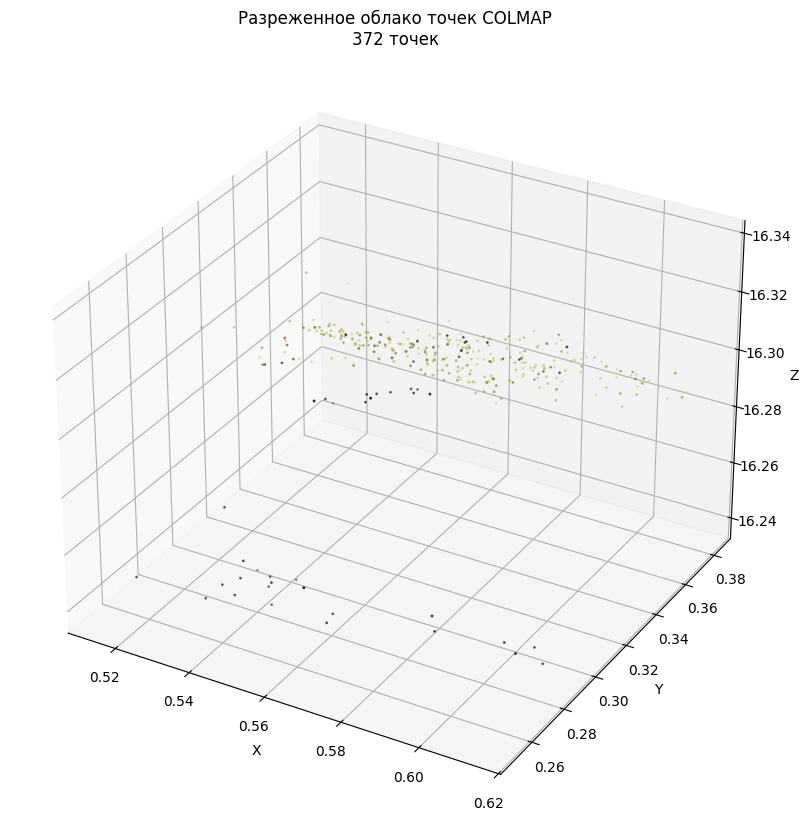


📊 Статистика облака точек:
  Всего точек: 372
  Диапазон X: [0.51, 0.61]
  Диапазон Y: [0.25, 0.38]
  Диапазон Z: [16.24, 16.34]


In [18]:
sparse_dir = "/content/gaussian_splatting/data/sparse"

# Визуализируем облако точек
pointcloud_data = visualize_colmap_results(
    sparse_dir,
    output_dir="/content/gaussian_splatting/data"
)

Таким образом в результате colmap наблюдаем разреженное облако точек, которое совсем не похоже на упаковку, как на фото

## 4. Gaussian Splatting Training

Перед запускрм эксперимента создадим директорию для сохранения результатов, инициализруем тренер и подготовим данные

In [26]:
print("🔄 Конвертация результатов COLMAP...")
binary_sparse = "/content/gaussian_splatting/data/sparse/0"
txt_sparse = "/content/gaussian_splatting/data/sparse_txt/0"

os.makedirs(txt_sparse, exist_ok=True)

convert_cmd = [
    "colmap", "model_converter",
    "--input_path", binary_sparse,
    "--output_path", txt_sparse,
    "--output_type", "TXT"
]

try:
    subprocess.run(convert_cmd, check=True, capture_output=True, text=True)
    print("✅ Конвертация завершена")
except Exception as e:
    print(f"⚠️ Конвертация не удалась: {e}")
    # Проверяем, может файлы уже в текстовом формате
    if not os.path.exists(os.path.join(txt_sparse, "cameras.txt")):
        print("❌ Не удалось получить текстовые файлы")
        exit(1)

🔄 Конвертация результатов COLMAP...
✅ Конвертация завершена


In [27]:
colmap_output = txt_sparse

# Создаем директорию для результатов
RESULTS_DIR = os.path.join(WORK_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# Инициализируем тренер
trainer = GaussianSplattingTrainer(DATA_DIR, RESULTS_DIR)

# Подготавливаем данные
gs_data = trainer.prepare_data_for_3dgs()

🔄 Конвертация бинарных файлов COLMAP в текстовый формат...
✅ Конвертация завершена
  Конвертирована камера 1 из PINHOLE в PINHOLE
  Скопирован images.txt
  Скопирован points3D.txt

✅ Данные подготовлены: /content/gaussian_splatting/results/gs_data
  Изображений: 50
  Модель камеры: PINHOLE


Проведем несколько экспериментов:
1. Короткое обучение 7к итераций, lr = 0.001
2. Полное обучение 15к итераций, lr = 0.001




In [28]:
exp1_dir = trainer.train_gaussian_splatting(
    gs_data,
    iterations=7000,
    lr_init=0.001
)

if exp1_dir:
    print(f"\n✅ Обучение завершено!")
    print(f"📁 Результаты: {exp1_dir}")

    # Анализируем количество гауссиан
    iterations, counts = trainer.analyze_splat_count(exp1_dir)
    if iterations:
        print(f"\n📊 Количество гауссиан:")
        for i, cnt in enumerate(counts):
            print(f"  Итерация {iterations[i]}: {cnt:,} гауссиан")

        # Визуализируем динамику
        plt.figure(figsize=(10, 6))
        plt.plot(iterations, counts, 'b-o')
        plt.xlabel('Итерации')
        plt.ylabel('Количество гауссиан')
        plt.title('Динамика количества гауссиан в процессе обучения')
        plt.grid(True, alpha=0.3)
        plt.show()
else:
    print("\n❌ Обучение не удалось")



🚀 Запуск обучения Gaussian Splatting
  Итераций: 7000
  Начальная learning rate: 0.001

Запуск команды:
python /content/gaussian-splatting/train.py -s /content/gaussian_splatting/results/gs_data -m /content/gaussian_splatting/results/iter_7000_lr_0.001 --iterations 7000 --position_lr_init 0.001 --eval


--- STDOUT ---
Optimizing /content/gaussian_splatting/results/iter_7000_lr_0.001
Output folder: /content/gaussian_splatting/results/iter_7000_lr_0.001 [27/03 08:43:46]

Reading camera 1/3
Reading camera 2/3
Reading camera 3/3 [27/03 08:43:46]
Loading Training Cameras [27/03 08:43:46]
Loading Test Cameras [27/03 08:43:46]
Number of points at initialisation :  372 [27/03 08:43:46]

[ITER 7000] Evaluating test: L1 0.24179990589618683 PSNR 11.0889892578125 [27/03 08:46:28]

[ITER 7000] Evaluating train: L1 0.007327671721577645 PSNR 33.531734466552734 [27/03 08:46:30]

[ITER 7000] Saving Gaussians [27/03 08:46:30]

Training complete. [27/03 08:46:31]


✅ Обучение завершено за 3.0 минут

✅ О

✅ Найден существующий рендер: /content/gaussian_splatting/results/iter_7000_lr_0.001/renders/point_cloud_views.png

📸 Используем рендер: /content/gaussian_splatting/results/iter_7000_lr_0.001/renders/point_cloud_views.png
✅ Сравнение сохранено: /content/gaussian_splatting/results/colmap_vs_gs_comparison.png


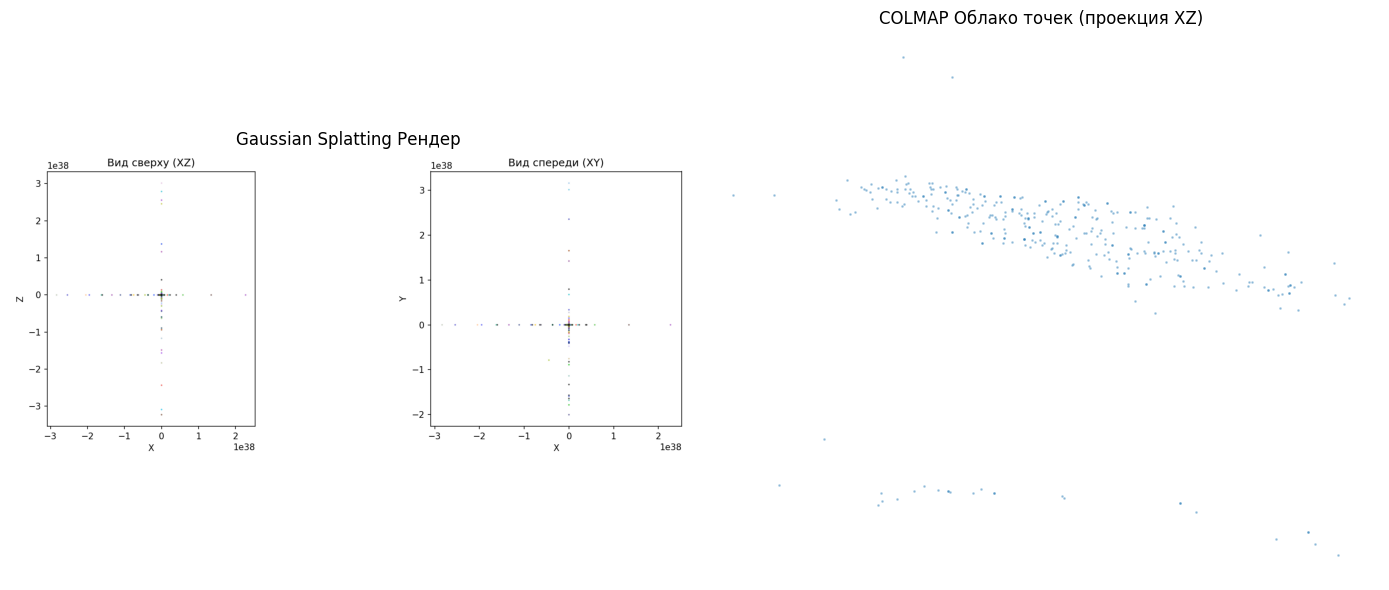

In [29]:
gs_render = find_or_generate_render_fixed(exp1_dir)
print(f"\n📸 Используем рендер: {gs_render}")

# Создаем сравнение с COLMAP
colmap_cloud = "/content/gaussian_splatting/data/sparse_txt/0/points3D.ply"
if not os.path.exists(colmap_cloud):
        colmap_cloud = "/content/gaussian_splatting/data/cameras.json"

visualize_comparison(
                colmap_cloud,
                gs_render,
                output_path=os.path.join(RESULTS_DIR, 'colmap_vs_gs_comparison.png')
                )

Таким образом, в результате сравнения методов видно, что ни один из них к сожалению не достиг результата. Возможно причина в датасете, поэтому не удается сформировать достаточное количество точек для формирования облака точек